# Sticky-strike vs sticky-moneyness PCA

The headline factor model (`pca_factors.ipynb`) fits vega-weighted PCA to surface changes at
**fixed (TTM, moneyness)** — *sticky-moneyness* coordinates. Its target is the `vol_surface`
piece of the attribution (daily std **$148k**), and the spot-driven smile slide (std $122k,
corr −0.89 with the surface piece) is left to the equity bucket via the smile delta. The
option's own fixed-strike vol change — attribution `vol` less term roll, std **$69k** — is the
*difference* of those two big offsetting pieces.

This notebook fits the same vega-weighted PCA in **sticky-strike** coordinates and compares.
Each pillar (τ, m) tracks the fixed strike K = m% of the *previous* close, so its daily change
samples the new surface at moneyness m·S₀/S₁:

$$\Delta\sigma^{ss}_{ij} \;=\; \sigma_t\!\left(\tau_i,\; m_j \tfrac{S_0}{S_1}\right) - \sigma_{t-1}(\tau_i, m_j)$$

i.e. surface change **plus smile slide**, term roll excluded. Both fits use the same weights
(the book's mean |bucket vega|) and the same fit sample, so every difference below is purely
the coordinate change.

The two coordinate systems imply different delta pairings — each pair is complete, with no
double counting inside it:

| vol coordinates | Δσ contains | paired delta | fixed-strike vol P&L target |
|---|---|---|---|
| sticky-moneyness | surface move only | smile delta (slide in equity) | `vol_surface` + slide handed over |
| sticky-strike | surface move + slide | plain BS delta | `vol − vol_roll` directly |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from vol_pca import load_surfaces, simulate_book, fit_pca, factor_vega_estimates
from vol_pca.factors import factor_scores, sticky_strike_dsigma
from vol_pca.attribution import independent_attribution
from vol_pca.surface import TTM_PILLARS, MONEYNESS

C_MON, C_SS, C_AUX = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUT = "#0b0b0b", "#898781"
DIV_CMAP = LinearSegmentedColormap.from_list("bwr_soft", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})
TTM_LBL = ["1M", "2M", "3M", "4M", "6M", "8M", "10M", "12M"]
MON_LBL = [str(int(m)) for m in MONEYNESS]
nt, nm = len(TTM_PILLARS), len(MONEYNESS)

sd = load_surfaces("SPX_volSurface 2.csv")
book, bucket_vega, dsigma = simulate_book(sd)
dsigma_ss = sticky_strike_dsigma(sd)
attr, _ = independent_attribution(sd)
normal = (book["gap_days"] <= 7).to_numpy()
ret = np.diff(np.log(sd.spot))

vega_w = np.abs(bucket_vega[normal]).mean(axis=0)
m_mon = fit_pca(dsigma, fit_mask=normal, weights=vega_w)
m_ss = fit_pca(dsigma_ss, fit_mask=normal, weights=vega_w)
for m in (m_mon, m_ss):                       # sign convention as in pca_factors
    for i in range(6):
        pat = m.components[i] / m.weights
        if pat[np.argmax(np.abs(pat))] < 0:
            m.components[i] *= -1

t_mon = attr["vol_surface"].to_numpy()        # own target, sticky-moneyness PCA
t_ss = (attr["vol"] - attr["vol_roll"]).to_numpy()   # own target, sticky-strike PCA
slide = attr["vol_slide"].to_numpy()

print(f"targets (daily std, normal days): vol_surface ${t_mon[normal].std():,.0f}   "
      f"fixed-strike vol ex roll ${t_ss[normal].std():,.0f}")
print(f"corr(vol_surface, vol_slide) = "
      f"{np.corrcoef(t_mon[normal], slide[normal])[0, 1]:.3f}")

targets (daily std, normal days): vol_surface $148,286   fixed-strike vol ex roll $68,698
corr(vol_surface, vol_slide) = -0.888


## How big are daily moves in each coordinate system?

Near the money the skew slide cancels most of the level move: **sticky-strike ATM pillar moves
are roughly half the size** of the fixed-moneyness ones — the classic observation that SPX
daily dynamics sit much closer to sticky-strike than to sticky-moneyness. The cancellation
fades in the wings (ratio up to ~1.2 in the far put wing at short TTM), and the 50/150 edge
columns are slightly damped by the lookup clamping at the quoted grid boundary.

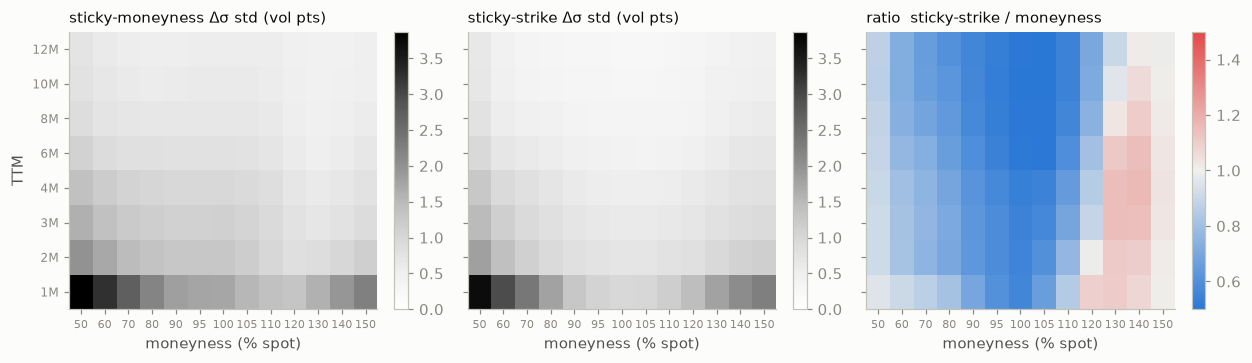

ATM (100%) daily vol-move std by TTM (vol pts):
     moneyness  sticky-strike  ratio
1M       1.728          0.977  0.566
2M       1.270          0.703  0.553
3M       1.105          0.605  0.547
4M       0.981          0.526  0.536
6M       0.788          0.401  0.510
8M       0.674          0.340  0.504
10M      0.597          0.300  0.503
12M      0.536          0.271  0.506


In [2]:
std_mon = dsigma[normal].std(axis=0).reshape(nt, nm) * 100
std_ss = dsigma_ss[normal].std(axis=0).reshape(nt, nm) * 100
vmax = max(std_mon.max(), std_ss.max())

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), sharey=True)
for ax, pat, title, kw in (
        (axes[0], std_mon, "sticky-moneyness Δσ std (vol pts)", dict(cmap="Greys", vmin=0, vmax=vmax)),
        (axes[1], std_ss, "sticky-strike Δσ std (vol pts)", dict(cmap="Greys", vmin=0, vmax=vmax)),
        (axes[2], std_ss / std_mon, "ratio  sticky-strike / moneyness", dict(cmap=DIV_CMAP, vmin=0.5, vmax=1.5))):
    im = ax.imshow(pat, origin="lower", aspect="auto", **kw)
    ax.set_xticks(range(nm), MON_LBL, fontsize=7)
    ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("moneyness (% spot)")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel("TTM")
plt.tight_layout(); plt.show()

atm = list(MONEYNESS).index(100.0)
tab = pd.DataFrame({"moneyness": std_mon[:, atm], "sticky-strike": std_ss[:, atm],
                    "ratio": std_ss[:, atm] / std_mon[:, atm]}, index=TTM_LBL)
print("ATM (100%) daily vol-move std by TTM (vol pts):")
print(tab.round(3).to_string())

## Factor shapes

Same vega-weighted fit, so both models spend their capacity where the book's dollar vega is.
PC1 is a level factor in both, but the sticky-strike version has **half the ATM amplitude and a
much flatter smile profile** — the skewed part of the level move is exactly what slide cancels.
Variance is also less concentrated: PC1 carries 93.5% of the $-weighted variance vs 98.1% in
moneyness coordinates, with PC2 (short-end + wings) and PC3 (call wing) picking up the rest.

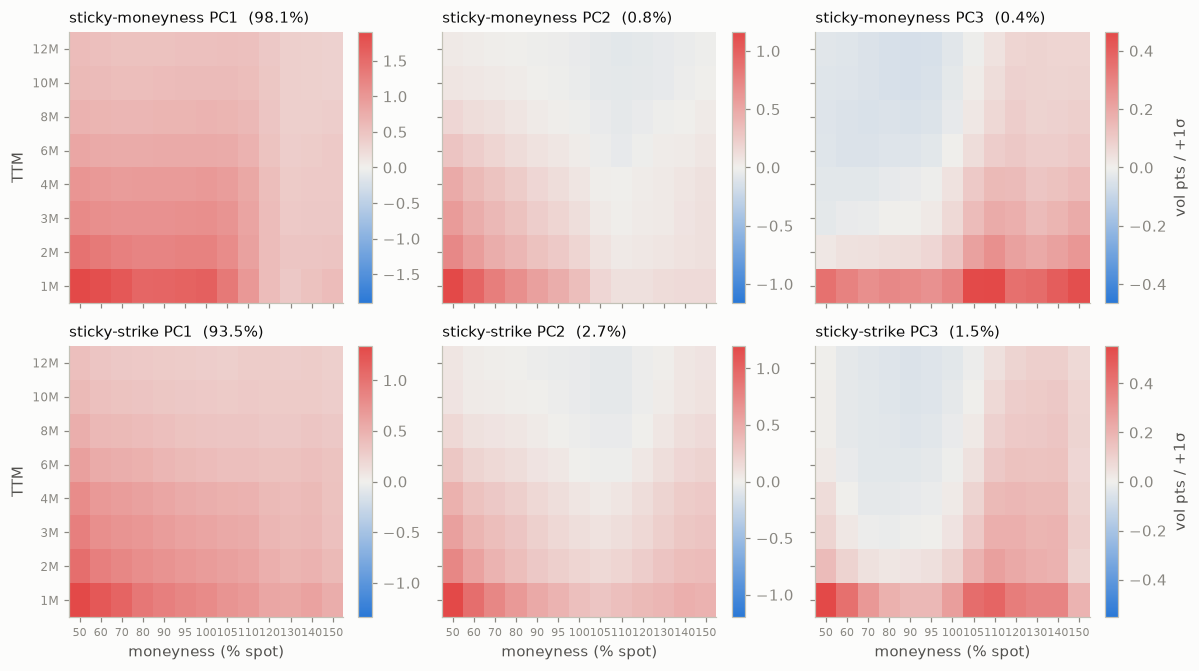

In [3]:
f_mon = factor_scores(dsigma, m_mon)
f_ss = factor_scores(dsigma_ss, m_ss)

fig, axes = plt.subplots(2, 3, figsize=(11, 6.2), sharex=True, sharey=True)
for row, (m, f, name) in enumerate(((m_mon, f_mon, "sticky-moneyness"),
                                    (m_ss, f_ss, "sticky-strike"))):
    for i in range(3):
        ax = axes[row, i]
        pat = (f[normal][:, i].std() * m.components[i] / m.weights * 100).reshape(nt, nm)
        v = np.abs(pat).max()
        im = ax.imshow(pat, origin="lower", aspect="auto", cmap=DIV_CMAP, vmin=-v, vmax=v)
        ax.set_xticks(range(nm), MON_LBL, fontsize=7)
        ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
        ax.set_title(f"{name} PC{i+1}  ({m.evr[i]:.1%})", loc="left", fontsize=10)
        ax.grid(False)
        fig.colorbar(im, ax=ax, label="vol pts / +1σ" if i == 2 else None, fraction=0.046)
    axes[row, 0].set_ylabel("TTM")
for i in range(3):
    axes[1, i].set_xlabel("moneyness (% spot)")
plt.tight_layout(); plt.show()

## Spot entanglement of the factor scores

In moneyness coordinates the level factor doubles as an equity factor: corr(PC1 score, spot
return) ≈ **−0.86**, because the surface level move is largely spot-driven. Sticky-strike
coordinates absorb that mechanical piece into the coordinate change itself, leaving factor
scores far closer to orthogonal to spot (PC1 ≈ −0.35, with the residual spot linkage spread
thinly over PC2/PC3).

This matters for *parametric* scenario design — shocking sticky-moneyness PC1 without
co-shocking spot describes a market state that essentially never occurs. It does **not**
matter for historical-simulation VaR, which replays each day's spot move and factor moves
jointly and so preserves the correlation automatically.

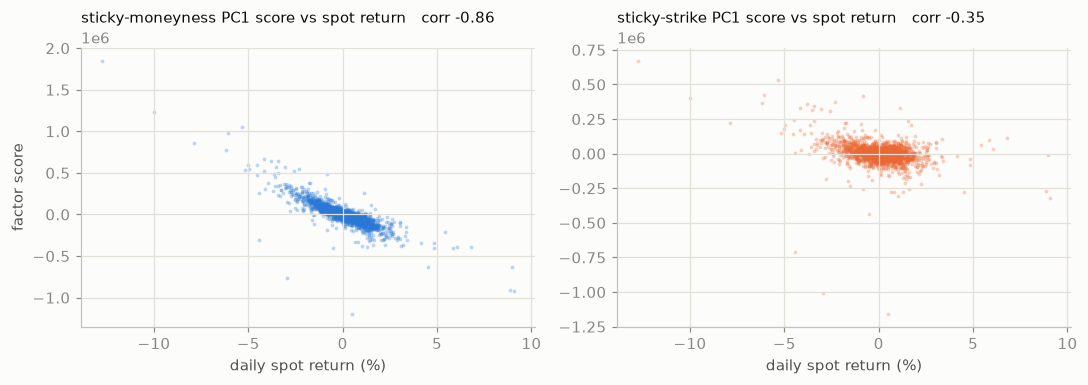

                  corr(f1, ret)  corr(f2, ret)  corr(f3, ret)  spot-return R² on f1..f3
sticky-moneyness         -0.857          0.076         -0.024                     0.740
sticky-strike            -0.354         -0.212         -0.215                     0.216


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=False)
for ax, f, name, c in ((axes[0], f_mon, "sticky-moneyness", C_MON),
                       (axes[1], f_ss, "sticky-strike", C_SS)):
    r = np.corrcoef(f[normal, 0], ret[normal])[0, 1]
    ax.scatter(ret[normal] * 100, f[normal, 0], s=6, alpha=0.3, color=c, lw=0)
    ax.set_title(f"{name} PC1 score vs spot return   corr {r:+.2f}", loc="left", fontsize=10)
    ax.set_xlabel("daily spot return (%)")
axes[0].set_ylabel("factor score")
plt.tight_layout(); plt.show()

rows = {}
for name, f in (("sticky-moneyness", f_mon), ("sticky-strike", f_ss)):
    cs = [np.corrcoef(f[normal, i], ret[normal])[0, 1] for i in range(3)]
    beta, *_ = np.linalg.lstsq(f[normal, :3], ret[normal], rcond=None)
    r2 = 1 - (ret[normal] - f[normal, :3] @ beta).var() / ret[normal].var()
    rows[name] = cs + [r2]
tab = pd.DataFrame(rows, index=["corr(f1, ret)", "corr(f2, ret)", "corr(f3, ret)",
                                "spot-return R² on f1..f3"]).T
print(tab.round(3).to_string())

## Estimate quality against the fixed-strike vol target

The economic quantity both setups ultimately serve is the book's fixed-strike vol P&L ex the
anticipatable term-roll carry: `vol − vol_roll` (std $69k). Three estimators:

1. **moneyness PCA alone** — predicts the $148k surface move; against the $69k fixed-strike
   target it is not just noisy but *anti*-explanatory (R² ≈ −2.5). This is the sharp version of
   the "difference of two large numbers" concern: surface factors alone cannot hit this target.
2. **moneyness PCA + slide** — the pairing the book actually uses: the smile-delta/equity side
   hands the slide over. Not a cheat in historical VaR: the replayed spot move plus the
   previous-close smile determine slide almost exactly.
3. **sticky-strike PCA** — self-contained, slide inside the factors.

Sticky-strike lands close to the paired setup at low k (0.76 vs 0.80 at k=3) but is slightly
behind at *every* k, and its ceiling is lower (0.92 vs 0.96 at all 104 factors): slide is a
spot×smile-shape interaction that linear factors span imperfectly.

R² by factor count (columns 2-4 vs the fixed-strike target, normal days):
     mon vs vol_surface (own target)  mon alone vs fixed-strike  mon + slide  sticky-strike
k                                                                                          
1                             0.8975                    -2.8906       0.5226         0.5187
2                             0.9146                    -2.6933       0.6023         0.5852
3                             0.9564                    -2.4555       0.7967         0.7620
5                             0.9687                    -2.4533       0.8541         0.8394
10                            0.9838                    -2.5191       0.9247         0.8763
104                           0.9905                    -2.5306       0.9557         0.9225


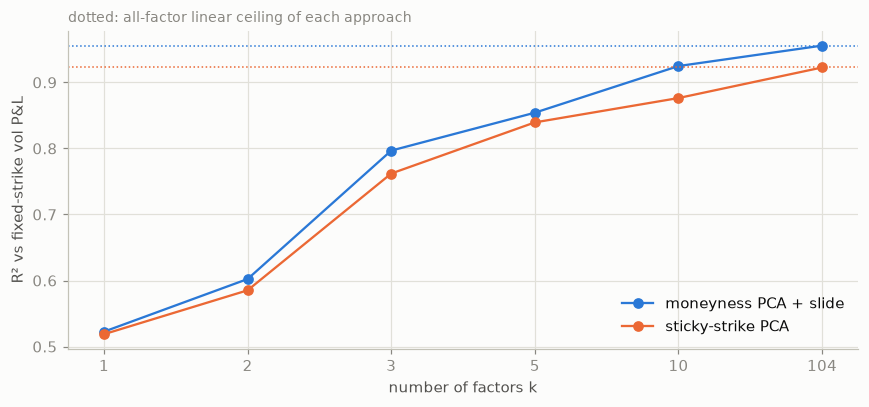

In [5]:
ks = [1, 2, 3, 5, 10, 104]
est_mon, _, _ = factor_vega_estimates(bucket_vega, dsigma, m_mon, ks)
est_ss, _, _ = factor_vega_estimates(bucket_vega, dsigma_ss, m_ss, ks)

def r2(t, e):
    return 1 - (t[normal] - e[normal]).var() / t[normal].var()

tab = pd.DataFrame({
    "mon vs vol_surface (own target)": [r2(t_mon, est_mon[k]) for k in ks],
    "mon alone vs fixed-strike": [r2(t_ss, est_mon[k]) for k in ks],
    "mon + slide": [r2(t_ss, est_mon[k] + slide) for k in ks],
    "sticky-strike": [r2(t_ss, est_ss[k]) for k in ks],
}, index=pd.Index(ks, name="k"))
print("R² by factor count (columns 2-4 vs the fixed-strike target, normal days):")
print(tab.round(4).to_string())

x = np.arange(len(ks))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(x, tab["mon + slide"], "o-", color=C_MON, label="moneyness PCA + slide")
ax.plot(x, tab["sticky-strike"], "o-", color=C_SS, label="sticky-strike PCA")
for col, c in (("mon + slide", C_MON), ("sticky-strike", C_SS)):
    ax.axhline(tab[col].iloc[-1], color=c, ls=":", lw=1)
ax.set_xticks(x, [str(k) for k in ks])
ax.set_xlabel("number of factors k")
ax.set_ylabel("R² vs fixed-strike vol P&L")
ax.set_title("dotted: all-factor linear ceiling of each approach", loc="left", fontsize=9, color=MUT)
ax.legend()
plt.tight_layout(); plt.show()

## Where the sticky-strike ceiling comes from

At the all-factor limit each model is exactly its linear bucketed-vega estimate, so the gap to
the nonlinear target isolates what the coordinates cost:

- **moneyness**: gap std **$14.5k** — pure vega convexity (the bucketed identity
  `pl_vega_lin = bucket_vega · Δσ` is exact to 1e-9 in these coordinates).
- **sticky-strike**: gap std **$19.1k** — convexity *plus* the loss of the exact identity:
  the rescaled lookup m·S₀/S₁ crosses interpolation brackets (and clamps at the 50/150 edges),
  so bucketed vegas no longer reproduce the per-option linear P&L. Both gaps grow with the
  size of the spot move (corr of |gap| with |return| ≈ 0.6) — precisely the days VaR cares
  about.

A second structural difference: the *mean* sticky-strike change contains the average
skew-slide drift — the base term `bucket_vega·μ` runs ≈ **+$8.8k/day** vs ≈ −$0.1k/day in
moneyness coordinates. Deterministic carry that the moneyness pairing keeps in the
equity/delta bucket ends up inside the sticky-strike factor model's mean.

linear-limit gap std: moneyness $14,466   sticky-strike $19,120
base drift bucket_vega·μ: moneyness $-78/day   sticky-strike $8,786/day


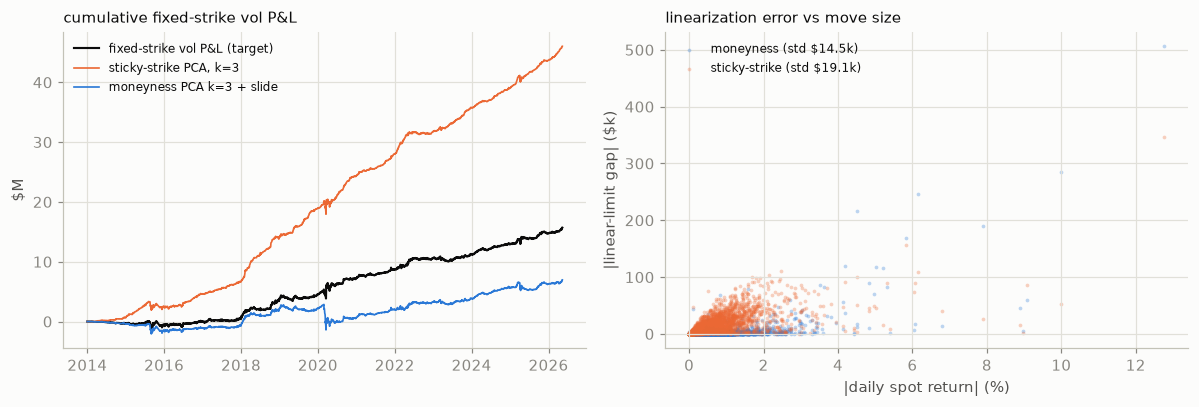

In [6]:
lin_mon, lin_ss = est_mon[104], est_ss[104]
gap_mon, gap_ss = t_mon - lin_mon, t_ss - lin_ss
print(f"linear-limit gap std: moneyness ${gap_mon[normal].std():,.0f}   "
      f"sticky-strike ${gap_ss[normal].std():,.0f}")
print(f"base drift bucket_vega·μ: moneyness ${(bucket_vega[normal] @ m_mon.mu).mean():,.0f}/day   "
      f"sticky-strike ${(bucket_vega[normal] @ m_ss.mu).mean():,.0f}/day")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
d = book.index
ax.plot(d, np.cumsum(t_ss) / 1e6, color=INK, lw=1.4, label="fixed-strike vol P&L (target)")
ax.plot(d, np.cumsum(est_ss[3]) / 1e6, color=C_SS, lw=1.1, label="sticky-strike PCA, k=3")
ax.plot(d, np.cumsum(est_mon[3] + slide) / 1e6, color=C_MON, lw=1.1, label="moneyness PCA k=3 + slide")
ax.set_title("cumulative fixed-strike vol P&L", loc="left", fontsize=10)
ax.set_ylabel("$M")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(np.abs(ret[normal]) * 100, np.abs(gap_mon[normal]) / 1e3, s=6, alpha=0.3,
           color=C_MON, lw=0, label=f"moneyness (std ${gap_mon[normal].std()/1e3:,.1f}k)")
ax.scatter(np.abs(ret[normal]) * 100, np.abs(gap_ss[normal]) / 1e3, s=6, alpha=0.3,
           color=C_SS, lw=0, label=f"sticky-strike (std ${gap_ss[normal].std()/1e3:,.1f}k)")
ax.set_xlabel("|daily spot return| (%)")
ax.set_ylabel("|linear-limit gap| ($k)")
ax.set_title("linearization error vs move size", loc="left", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Are the factors stable?

A worry with sticky-strike coordinates is that the Δσ depend on realized spot dynamics, so the
factors might drift with the spot-vol regime. Splitting the sample in half and refitting (same
weights) shows loading stability is in fact **comparable** — PC1 is rock solid in both systems
and the higher factors are similarly soft:

In [7]:
idx = np.flatnonzero(normal)
h1 = np.zeros_like(normal); h1[idx[:len(idx) // 2]] = True
h2 = np.zeros_like(normal); h2[idx[len(idx) // 2:]] = True
rows = {}
for name, ds in (("sticky-moneyness", dsigma), ("sticky-strike", dsigma_ss)):
    a = fit_pca(ds, fit_mask=h1, weights=vega_w)
    b = fit_pca(ds, fit_mask=h2, weights=vega_w)
    rows[name] = [abs(np.corrcoef(a.components[i], b.components[i])[0, 1]) for i in range(3)]
tab = pd.DataFrame(rows, index=["PC1", "PC2", "PC3"]).T
print("|corr| of factor loadings, first half vs second half of the sample:")
print(tab.round(3).to_string())

|corr| of factor loadings, first half vs second half of the sample:
                    PC1    PC2    PC3
sticky-moneyness  0.999  0.988  0.879
sticky-strike     0.999  0.919  0.900


## Takeaways

- **The sticky-strike view directly addresses the "difference of two large numbers" concern**:
  the $69k fixed-strike target is modeled in its own coordinates, where near-ATM daily moves
  really are ~½ the fixed-moneyness ones and no $148k/$122k cancellation is involved.
- **But as an estimator it is slightly worse at every k** than the paired setup (moneyness PCA
  + slide handed over from the equity side): R² 0.76 vs 0.80 at k=3, ceiling 0.92 vs 0.96.
  Slide is a spot×smile interaction that linear factors span imperfectly, and the rescaled
  pillar lookup gives up the exact bucketed-vega identity — with the extra error concentrated
  on large spot-move days, where VaR lives.
- **Sticky-strike factors are far less spot-entangled** (top-3 scores span ~22% of spot-return
  variance vs ~74%; PC1 |corr| 0.35 vs 0.86). That is genuinely attractive for parametric
  stress design, where factors are shocked independently of spot. Historical simulation is
  indifferent — it replays spot and factor moves jointly.
- **Bookkeeping differs**: the skew-slide carry (≈ +$8.8k/day) moves inside the sticky-strike
  factor mean, and exposures pair with the plain BS delta rather than the smile delta the book
  attribution hedges with.
- **Verdict**: keep vega-weighted sticky-moneyness PCA + smile delta as the headline risk
  model; use sticky-strike as a cross-check on the fixed-strike target and as the cleaner,
  more spot-orthogonal coordinate system for parametric scenarios.